In [28]:
import numpy as np
import pandas as pd

import pypsa

#Calcola il costo annuo equivalente di un investimento
def annuity(capex, lifetime, wacc):
    return capex * (wacc * (1 + wacc)**lifetime) / ((1 + wacc)**lifetime - 1)

n = pypsa.Network()

n.add("Carrier", "grid", color="blue")
n.add("Carrier", "solar", color="yellow")
n.add("Carrier", "battery", color="green")

#Crea linea "seville", carico "demand" da 100MW e generatore "grid" da 100MW a 120€/MWh sulla linea seville 
n.add("Bus", "seville")

n.add("Load", "demand", bus="seville", p_set=100)

n.add("Generator", "grid", bus="seville", p_nom=100, marginal_cost=120, carrier="grid");

In [29]:
#legge capacity factor del generatore solar
p_max_pu = pd.read_csv(
    "https://model.energy/data/time-series-f17c3736a2719ce7da58484180d89e2d.csv",
    index_col=0,
    parse_dates=True,
)["solar"]
p_max_pu[7:15]

time
2011-01-01 07:00:00    0.000
2011-01-01 08:00:00    0.000
2011-01-01 09:00:00    0.048
2011-01-01 10:00:00    0.118
2011-01-01 11:00:00    0.214
2011-01-01 12:00:00    0.243
2011-01-01 13:00:00    0.219
2011-01-01 14:00:00    0.138
Name: solar, dtype: float64

In [30]:
#dice al modello che questi sono gli snapshots (time steps) da ottimizzare
n.set_snapshots(p_max_pu.index)
len(n.snapshots)

8760

In [31]:
#aggiunge generatore "solar" sulla linea seville, con 25 anni lifetime, 5% discount rate, 400€/kw overnight cost
n.add(
    "Generator",
    "solar",
    bus="seville",
    p_max_pu=p_max_pu,
    capital_cost=annuity(400_000,25,0.05),
    p_nom_extendable=True,
    carrier="solar",
);

In [32]:
#aggiunge batterie e inverter per storage a linea seville
cc_inverter = annuity(170_000,25,0.05)
cc_storage = annuity(150_000,25,0.05)

n.add(
    "StorageUnit",
    "battery",
    bus="seville",
    capital_cost=cc_inverter + 4 * cc_storage,
    p_nom_extendable=True,
    carrier="battery",
    efficiency_store=np.sqrt(0.9),
    efficiency_dispatch=np.sqrt(0.9),
    max_hours=4,
);

In [33]:
n.optimize(log_to_console=False)

Index(['seville'], dtype='object', name='Bus')
Index(['seville'], dtype='object', name='Bus')
c:\Users\Lella\anaconda3\envs\pypsa-earth\Lib\site-packages\linopy\expressions.py:1955: DeprecationWarning: Using merge without specifying the class is deprecated
  warn(
c:\Users\Lella\anaconda3\envs\pypsa-earth\Lib\site-packages\linopy\expressions.py:1955: DeprecationWarning: Using merge without specifying the class is deprecated
  warn(
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 26.18it/s]
INFO:linopy.io: Writing time: 1.43s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43802 primals, 105122 duals
Objective: 4.83e+07
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p

('ok', 'optimal')

In [34]:
#mostra risultati ottimizzazione generatori e storage
display(n.generators.p_nom_opt)
display(n.storage_units.p_nom_opt)

Generator
grid     100.000000
solar    659.778414
Name: p_nom_opt, dtype: float64

StorageUnit
battery    351.371839
Name: p_nom_opt, dtype: float64

In [35]:
#mostra direttamente capacità installata
n.statistics.optimal_capacity()

component    carrier
Generator    grid       100.00000
             solar      659.77841
StorageUnit  battery    351.37184
dtype: float64

In [36]:
#mostra costi
totex = {"opex": n.statistics.opex(), "capex": n.statistics.capex()}
pd.concat(totex, axis=1).div(1e6).round(2)  # M€/a

opex  capex
component   carrier              
Generator   grid     10.36    NaN
            solar      NaN  18.73
StorageUnit battery    NaN  19.20

In [37]:
#bilancio energetico del sistema
n.statistics.energy_balance().div(1e3)  # GWh

component    carrier  bus_carrier
Load         -        AC            -876.000000
Generator    grid     AC              86.354010
             solar    AC             836.363402
StorageUnit  battery  AC             -46.717412
dtype: float64

<Axes: xlabel='snapshot'>

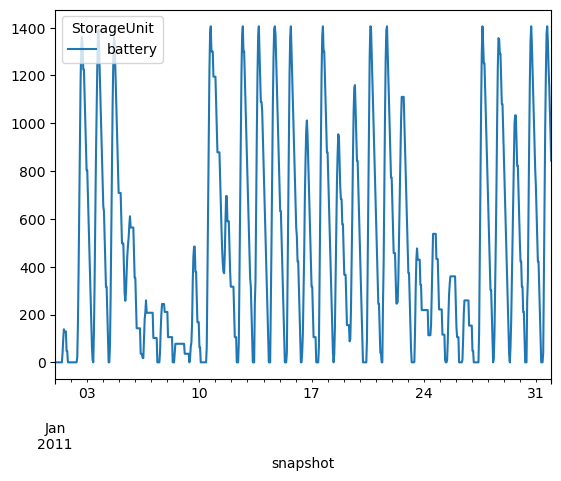

In [38]:
#profilo carica batterie a gennaio
n.storage_units_t.state_of_charge.loc["2011-01"].plot()

<Axes: xlabel='component,carrier,bus_carrier'>

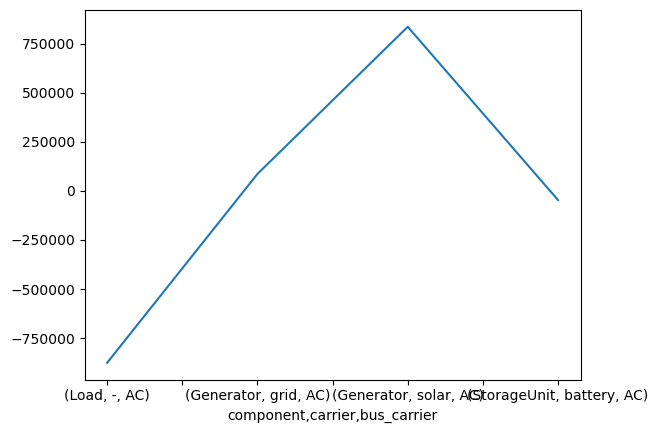

In [39]:
n.carriers.loc["grid", "color"] = "blue"
n.carriers.loc["solar", "color"] = "yellow"
n.carriers.loc["battery", "color"] = "green"

eb = n.statistics.energy_balance()
eb.plot()

In [42]:
n.export_to_excel("data-centre-investment.xlsx")
n.export_to_netcdf("data-centre-investment.nc")

o = pypsa.Network("data-centre-investment.nc")


AttributeError: 'Network' object has no attribute 'export_to_excel'